# Практическая работа №7

**Цель работы:** изучить и сравнить эффективность архитектур нейронных сетей для решения задачи бинарной классификации на подготовленном датасете. Оценить влияние архитектурных решений и автоматического подбора гиперпараметров на качество и устойчивость моделей.

**Задачи работы:**

1. Провести расширенный анализ и предобработку данных.
2. Обучить две разные архитектуры глубоких нейронных сетей.
3. Провести автоматический подбор гиперпараметров и архитектуры с помощью Optuna.
5. Оценить модели по выбранным метрикам качества.
6. Исследовать устойчивость моделей: добавление шума или уменьшение размера обучающей выборки, проверка склонности к переобучению.
6. Построить графики обучения, валидации, переобучения и сравнить модели.
7. Сформировать обоснованные выводы об эффективности каждой архитектуры.

**Используемые алгоритмы:**

1. **Архитектура 1: MLP + 1D CNN**. 1D CNN сверточная нейронная сеть обрабатывает данные локальными фильтрами, выявляя шаблоны в строке признаков. Свертки помогают выявить характерные комбинации признаков, которые часто встречаются вместе. MLP — многослойный перцептрон. После CNN данные передаются в полносвязные слои, которые агрегируют признаки и принимают финальное решение о классе. Архитектура быстрая и хорошо работает на табличных данных.

2. **Архитектура 2: CNN + Bidirectional LSTM.** CNN выполняет предварительное выделение признаков, упрощая задачу рекуррентной сети. Bidirectional LSTM — это рекуррентная нейросеть, которая учитывает последовательность данных в двух направлениях: вперёд и назад. Позволяет модели улавливать зависимости между признаками по всей последовательности данных. Комбинация CNN + BiLSTM часто используется в задачах анализа временных рядов, но может давать хорошие результаты и на табличных данных.

3. **Optuna:** библиотека для автоматического подбора гиперпараметров с использованием методов оптимизации на основе истории предыдущих экспериментов. Итеративно выбирает комбинации параметров, обучает модель и оценивает качество, стремясь минимизировать или максимизировать заданную метрику.

**Основные метрики:**

- **F1-score** для класса «дождь» — основная метрика, так как классы несбалансированы. Учитывает и precision, и recall.  
- **Accuracy** — общая оценка, но второстепенная при дисбалансе.
- **ROC-AUC и PR-AUC** — вспомогательные метрики для общего качества и поведения при дисбалансе.

Датасет (из 1 работы): https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/data

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.6 MB/s eta 0:00:00


In [ ]:
# Используемые библиотеки
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import optuna

## 1. Загрузка и подготовка данных

Ранее для данного датасета Rain in Australia была проведена предобработка данных: обработаны пропуски, удалены выбросы, категориальные признаки преобразованы с помощью One-Hot Encoding и стандартизированы, удалены ненужные и сильно коррелированные признаки, дата преобразована в числовой формат. Данные разделены на обучающую (train), валидационную (valid) и тестовую (test) выборки.

Архитектуры CNN+BiLSTM и MLP+1D-CNN ожидают последовательные данные: наличие информации о прошлых днях улучшает предсказание. Сформируем окна по каждой локации, чтобы не смешивать данные разных мест.

Расширенный препроцессинг данных: сформируем временные окна (последовательности) по каждой локации, `window_size = 5` (последние 5 дней). Получим `X_seq` (samples, window_size, features_per_day) для Conv1D/BiLSTM и `X_tab` (samples, features_tab) — табличные признаки текущего дня для MLP. Подготовим объекты для train/val/test.



Shapes: (96691, 60) (24173, 60) (21329, 60)


,Rainfall,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Cloud3pm,Temp3pm,RainToday,Location_Albany,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
10832,2.540517,-2.830020,0.769071,1.221947,0.511072,0.926395,1.028669,-0.780448,1,False,...,False,False,False,False,False,False,False,2011,6,13
64426,5.047411,0.173575,1.301877,0.272726,0.024543,-1.297080,0.719060,-0.083081,1,False,...,False,False,False,False,False,False,False,2017,1,17
61488,-0.279738,1.850000,0.236264,-1.098371,-0.559292,-0.911678,-0.828984,0.730514,0,False,...,False,False,False,False,False,False,False,2015,1,1
81810,-0.279738,-0.769414,0.084034,0.483664,1.484131,0.600286,1.028669,-1.448758,0,False,...,False,False,False,False,False,False,False,2013,6,16
70346,0.612137,-0.420159,-0.068197,1.274681,1.143560,0.363115,0.099843,-0.649691,1,False,...,False,False,False,False,False,False,False,2012,8,4


,RainTomorrow
10832,1
64426,1
61488,0
81810,1
70346,1


Location cols: 48
Year/Month/Day in columns: True


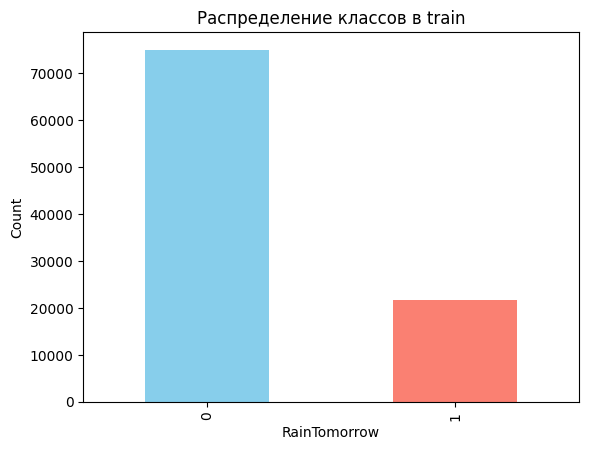

In [ ]:
# Загрузка
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/train_reduced.pkl -O train_reduced.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/val_reduced.pkl -O val_reduced.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/test_reduced.pkl -O test_reduced.pkl

X_train, y_train = joblib.load("train_reduced.pkl")
X_val, y_val = joblib.load("val_reduced.pkl")
X_test, y_test = joblib.load("test_reduced.pkl")

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
display(X_train.head())
display(y_train.head())

# Проверим колонки Location_ и Year/Month/Day
loc_cols = [c for c in X_train.columns if c.startswith("Location_")]
print("Location cols:", len(loc_cols))
print("Year/Month/Day in columns:", set(['Year','Month','Day']).issubset(set(X_train.columns)))

# Распределение целевого признака
pd.Series(y_train).value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Распределение классов в train")
plt.xlabel("RainTomorrow")
plt.ylabel("Count")
plt.show()

Сформируем окна (последовательности) по Location. Используем one-hot Location_ колонки для группировки по локациям. В seq_cols исключим Location_ и Year/Month/Day, чтобы последовательности содержали только погодные и закодированные признаки. Окно включает последние window_size дней, где последняя запись это текущий день.

In [ ]:
#  Если в X есть one-hot колонки Location, вернём для каждой строки имя колонки с 1 (конвертируем обратно one-hot в обычную категорию)
def infer_location_series(X_df, location_prefix='Location_'):
    loc_cols = [c for c in X_df.columns if c.startswith(location_prefix)]
    loc_ser = X_df[loc_cols].idxmax(axis=1)
    loc_ser = loc_ser.str.replace(location_prefix, '', regex=False)
    return loc_ser

# Группируем данные по локациям, сортирует по времени, строим временные окна фиксированной длины, создаём два набора признаков X_seq и X_tab
def create_sequences_per_df(X_df, y_ser, window_size=5, location_prefix='Location_', drop_cols_for_seq=None, sort_by=['Year','Month','Day']):
    if drop_cols_for_seq is None:
        drop_cols_for_seq = []
    loc_labels = infer_location_series(X_df, location_prefix=location_prefix)
    X_seq_list, X_tab_list, y_list, idx_list = [], [], [], []
    all_cols = X_df.columns.tolist()
    seq_cols = [c for c in all_cols if c not in drop_cols_for_seq]
    groups = X_df.groupby(loc_labels)
    for loc, idxs in tqdm.tqdm(groups.groups.items(), desc="Locations"):
        group_idx = groups.groups[loc]
        group_df = X_df.loc[group_idx].copy()
        if all(c in group_df.columns for c in sort_by):
            group_df = group_df.sort_values(sort_by)
            sub_idx = group_df.index.to_list()
        else:
            sub_idx = group_idx.tolist()
        group_y = pd.Series(y_ser).loc[sub_idx]
        seq_vals = group_df[seq_cols].values
        n = seq_vals.shape[0]
        if n < window_size:
            continue
        for i in range(window_size-1, n):
            window = seq_vals[i-window_size+1 : i+1]
            X_seq_list.append(window)
            X_tab_list.append(seq_vals[i])
            y_list.append(group_y.iloc[i])
            idx_list.append(sub_idx[i])

    X_seq_arr = np.asarray(X_seq_list)
    X_tab_arr = np.asarray(X_tab_list)
    y_arr = np.asarray(y_list).astype(int)
    print("Создано:", X_seq_arr.shape, "X_tab:", X_tab_arr.shape, "y:", y_arr.shape)
    return X_seq_arr, X_tab_arr, y_arr, idx_list, seq_cols

# Применим функцию к train, val, test
window_size = 5
drop_cols = loc_cols + ['Year','Month','Day']
X_train_seq, X_train_tab, y_train_seq, train_idx, seq_cols = create_sequences_per_df(X_train, y_train, window_size=window_size, drop_cols_for_seq=drop_cols)
X_val_seq, X_val_tab, y_val_seq, val_idx, _ = create_sequences_per_df(X_val, y_val, window_size=window_size, drop_cols_for_seq=drop_cols)
X_test_seq, X_test_tab, y_test_seq, test_idx, _ = create_sequences_per_df(X_test, y_test, window_size=window_size, drop_cols_for_seq=drop_cols)

Locations: 100%|██████████| 48/48 [00:00<00:00, 49.38it/s]


Создано: (96499, 5, 9) X_tab: (96499, 9) y: (96499,)


Locations: 100%|██████████| 48/48 [00:00<00:00, 89.40it/s]


Создано: (23981, 5, 9) X_tab: (23981, 9) y: (23981,)


Locations: 100%|██████████| 48/48 [00:00<00:00, 48.60it/s]


Создано: (21137, 5, 9) X_tab: (21137, 9) y: (21137,)


Финальная подготовка и создание tf.data.Dataset.

In [ ]:
print("Train seq:", X_train_seq.shape, "Train tab:", X_train_tab.shape, "y:", y_train_seq.shape)
print("Val seq:", X_val_seq.shape, "Val tab:", X_val_tab.shape, "y:", y_val_seq.shape)
print("Test seq:", X_test_seq.shape, "Test tab:", X_test_tab.shape, "y:", y_test_seq.shape)

# Создание tf.data.Dataset
def make_tf_dataset(X_seq, X_tab, y, batch_size=32, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices(((X_seq, X_tab), y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(y), seed=42)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

batch = 32
train_ds = make_tf_dataset(X_train_seq, X_train_tab, y_train_seq, batch_size=batch, shuffle=True)
val_ds = make_tf_dataset(X_val_seq, X_val_tab, y_val_seq, batch_size=batch, shuffle=False)
test_ds = make_tf_dataset(X_test_seq, X_test_tab, y_test_seq, batch_size=batch, shuffle=False)

for (x_seq_batch, x_tab_batch), yb in train_ds.take(1):
    print("x_seq batch:", x_seq_batch.shape)
    print("x_tab batch:", x_tab_batch.shape)
    print("y batch:", yb.shape)

Train seq: (96499, 5, 9) Train tab: (96499, 9) y: (96499,)
Val seq: (23981, 5, 9) Val tab: (23981, 9) y: (23981,)
Test seq: (21137, 5, 9) Test tab: (21137, 9) y: (21137,)
x_seq batch: (32, 5, 9)
x_tab batch: (32, 9)
y batch: (32,)


Подготовили датасеты в формате, подходящем для глубоких нейронных сетей: последовательные признаки имеют форму (32, 5, 9) — 5-дневное окно по 9 показателям, табличные признаки — (32, 9), целевой вектор y — (32,). Создали tf.data.Dataset для обучения, валидации и теста. Размеры батча также корректны. Данные готовы для подачи в глубокую архитектуру.

## 2. MLP + 1D CNN

Процесс работы комбинированной модели: пропускаем последовательные признаки через 1D CNN и получаем признаки по окну, пропускаем табличные признаки через MLP, объединяем оба выхода, подаём в финальный классификатор. Так модель одновременно понимает динамику погоды во времени и анализирует статичные параметры текущего дня.

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_72      │ (None, 5, 9)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_72 (Conv1D)  │ (None, 5, 32)     │        608 │ input_layer_72[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_73 (Conv1D)  │ (None, 5, 64)     │      4,160 │ conv1d_72[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_73[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_73      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_144 (Dense)   │ (None, 32)        │      2,080 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_145 (Dense)   │ (None, 32)        │        320 │ input_layer_73[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_36      │ (None, 64)        │          0 │ dense_144[0][0],  │
│ (Concatenate)       │                   │            │ dense_145[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_146 (Dense)   │ (None, 32)        │      2,080 │ concatenate_36[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 32)        │          0 │ dense_146[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_147 (Dense)   │ (None, 1)         │         33 │ dropout_36[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,281 (36.25 KB)

 Trainable params: 9,281 (36.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - AUC: 0.8335 - accuracy: 0.8304 - loss: 0.3893 - val_AUC: 0.8641 - val_accuracy: 0.8422 - val_loss: 0.3602
Epoch 2/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - AUC: 0.8606 - accuracy: 0.8429 - loss: 0.3635 - val_AUC: 0.8662 - val_accuracy: 0.8434 - val_loss: 0.3579
Epoch 3/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - AUC: 0.8681 - accuracy: 0.8454 - loss: 0.3548 - val_AUC: 0.8667 - val_accuracy: 0.8455 - val_loss: 0.3568
Epoch 4/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - AUC: 0.8706 - accuracy: 0.8464 - loss: 0.3515 - val_AUC: 0.8663 - val_accuracy: 0.8442 - val_loss: 0.3577
Epoch 5/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - AUC: 0.8710 - accuracy: 0.8481 - loss: 0.3514 - val_AUC: 0.8676 - val_accuracy: 0.8455 - val_loss: 0.3550
Epoch 6/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - AUC: 0.8733 - accuracy: 0.8506 - loss: 0.3468 - val_AUC: 0.8675 - val_accuracy: 0.8447 - val_loss: 0.3563
Epoch 7/20
3016/3016 ━

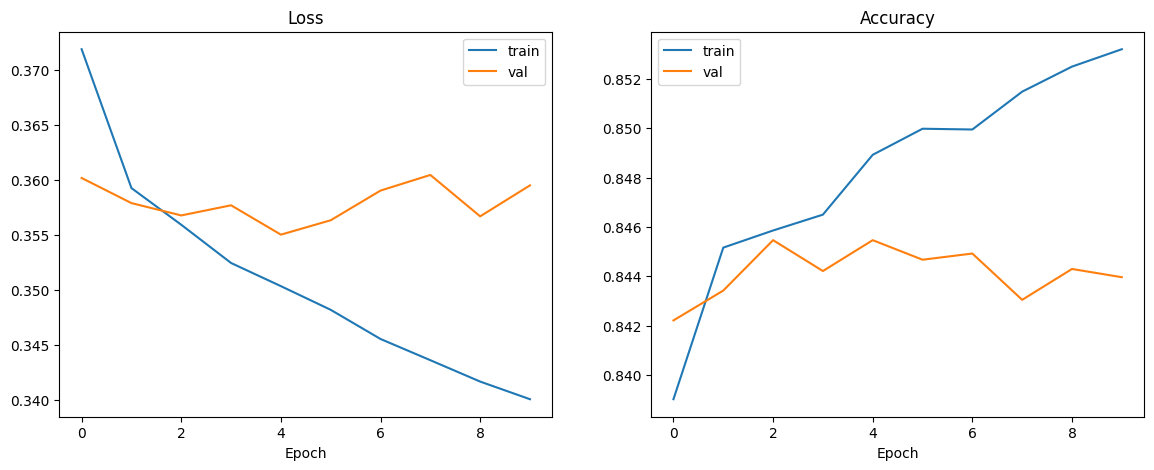

661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.8776 - accuracy: 0.8479 - loss: 0.3440

Test metrics: [0.3480868339538574, 0.8481336236000061, 0.8734830617904663]
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     16389
           1       0.75      0.49      0.59      4748

    accuracy                           0.85     21137
   macro avg       0.81      0.72      0.75     21137
weighted avg       0.84      0.85      0.84     21137

F1-score: 0.5924327069578467


In [ ]:
# Создание модели MLP + 1D CNN
def build_mlp_cnn_model(seq_shape=(5, 9), tab_shape=(9,)):
    # Последовательные признаки
    inp_seq = layers.Input(shape=seq_shape)
    x = layers.Conv1D(filters=32, kernel_size=2, activation='relu', padding='same')(inp_seq)
    x = layers.Conv1D(filters=64, kernel_size=2, activation='relu', padding='same')(x)
    x = layers.GlobalMaxPooling1D()(x)
    seq_out = layers.Dense(32, activation='relu')(x)

    # Табличные признаки
    inp_tab = layers.Input(shape=tab_shape)
    tab_out = layers.Dense(32, activation='relu')(inp_tab)

    # Объединение
    combined = layers.concatenate([seq_out, tab_out])
    combined = layers.Dense(32, activation='relu')(combined)
    combined = layers.Dropout(0.2)(combined)

    # Выход
    output = layers.Dense(1, activation='sigmoid')(combined)
    model = models.Model(inputs=[inp_seq, inp_tab], outputs=output)
    return model

model = build_mlp_cnn_model()
model.summary()

# Компиляция
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="AUC")]
)

# Обучение модели
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True,
            monitor="val_loss"
        )
    ]
)

# Графики обучения
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.show()

# Оценка на тестовой выборке
test_metrics = model.evaluate(test_ds)
print("\nTest metrics:", test_metrics)

y_pred = model.predict(test_ds)
y_pred_labels = (y_pred > 0.5).astype(int).flatten()
print("\nClassification report:")
print(classification_report(y_test_seq, y_pred_labels))
print("F1-score:", f1_score(y_test_seq, y_pred_labels))

Класс 0 (нет дождя): precision 0.87, recall 0.95, f1 0.91

Класс 1 (дождь): precision 0.74, recall 0.50, f1 0.59

Итоговый F1 (для класса 1) около 0.59. Модель хорошо отделяет основной класс 0 и держит высокую общую точность, но пропускает много реальных дождей.

Loss на графике:

Train loss плавно уменьшается от эпохи к эпохе, признак хорошей сходимости. Val loss сначала немного падает, затем держится почти ровно, в конце начинает расти. Модель обучается стабильно, нет скачков или провалов, но начало лёгкого переобучения. Достигла оптимума примерно на 3-4 эпохах, далее обучение почти ничего не улучшает, а начинает ухудшать val loss.

Accuracy на графике:

Train accuracy стабильно растёт. Val accuracy растёт первые 3–4 эпохи, затем чуть падает и фиксируется около 0.844.

Лучшие результаты на валидации — 3–4 эпоха, дальше улучшений нет. Val loss начинает расти при стабильной val accuracy, модель подбирается к лимиту качества, и дальнейшее обучение не помогает.

Таким образом, модель демонстрирует устойчивое обобщение, однако по дополнительным метрикам видно, что она недостаточно чувствительна к редкому классу.

## 3. CNN + Bidirectional LSTM

CNN отвечает за извлечение паттернов во временной последовательности, выявляет быстрые изменения и локальные тренды между соседними временными шагами. Bidirectional LSTM анализирует последовательность как в прямом, так и в обратном направлении, позволяет учесть контекст, что эффективно в задачах прогнозирования, где важны не только предыдущие шаги, но и общая структура.

Табличные данные (X_tab) обрабатываются отдельным MLP-блоком, затем объединяются с выходом от BiLSTM. Это даёт модели знание о текущих значениях, а не только о временной истории.

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_76      │ (None, 5, 9)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_76 (Conv1D)  │ (None, 4, 32)     │        608 │ input_layer_76[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_77 (Conv1D)  │ (None, 3, 64)     │      4,160 │ conv1d_76[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_77      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128)       │     66,048 │ conv1d_77[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_152 (Dense)   │ (None, 64)        │        640 │ input_layer_77[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 128)       │          0 │ bidirectional_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_153 (Dense)   │ (None, 32)        │      2,080 │ dense_152[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_38      │ (None, 160)       │          0 │ dropout_38[0][0], │
│ (Concatenate)       │                   │            │ dense_153[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_154 (Dense)   │ (None, 64)        │     10,304 │ concatenate_38[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_155 (Dense)   │ (None, 1)         │         65 │ dense_154[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 83,905 (327.75 KB)

 Trainable params: 83,905 (327.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8322 - loss: 0.3796 - val_accuracy: 0.8416 - val_loss: 0.3601
Epoch 2/7
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.8481 - loss: 0.3541 - val_accuracy: 0.8445 - val_loss: 0.3572
Epoch 3/7
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.8479 - loss: 0.3518 - val_accuracy: 0.8427 - val_loss: 0.3581
Epoch 4/7
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.8508 - loss: 0.3447 - val_accuracy: 0.8442 - val_loss: 0.3577
Epoch 5/7
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - accuracy: 0.8493 - loss: 0.3469 - val_accuracy: 0.8446 - val_loss: 0.3588
Epoch 6/7
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.8526 - loss: 0.3410 - val_accuracy: 0.8453 - val_loss: 0.3564
Epoch 7/7
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - accuracy: 0.8526 - loss: 0.3414 - val_accuracy: 0.8444 - val_loss: 0.3551


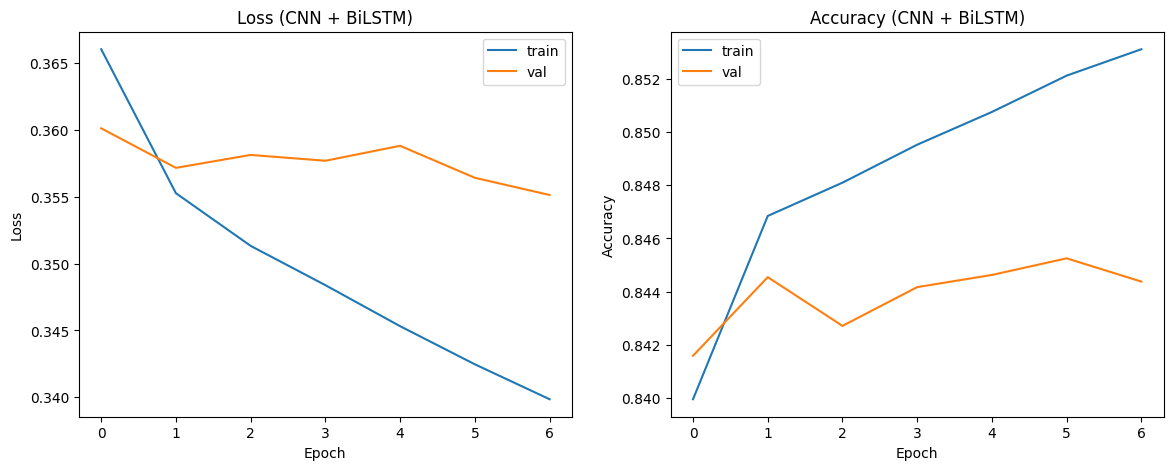

661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8492 - loss: 0.3425

Test metrics: [0.34650498628616333, 0.8509722352027893]
661/661 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     16389
           1       0.74      0.52      0.61      4748

    accuracy                           0.85     21137
   macro avg       0.81      0.73      0.76     21137
weighted avg       0.84      0.85      0.84     21137

F1-score: 0.6114948199309325


In [ ]:
def build_bilstm_model():
    # Входы
    seq_input = layers.Input(shape=(5, 9))
    tab_input = layers.Input(shape=(9,))

    # CNN + BiLSTM для последовательных данных
    x = layers.Conv1D(filters=32, kernel_size=2, activation='relu')(seq_input)
    x = layers.Conv1D(filters=64, kernel_size=2, activation='relu')(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.3)(x)

    # Табличные признаки
    t = layers.Dense(64, activation='relu')(tab_input)
    t = layers.Dense(32, activation='relu')(t)

    # Объединение
    combined = layers.Concatenate()([x, t])

    # Финальные слои
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dense(1, activation='sigmoid')(out)

    model = models.Model(inputs=[seq_input, tab_input], outputs=out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model_bilstm = build_bilstm_model()

model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bilstm.summary()

# Обучение
history_bilstm = model_bilstm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=7,
    verbose=1
)

# Графики обучения
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_bilstm.history["loss"], label="train")
plt.plot(history_bilstm.history["val_loss"], label="val")
plt.title("Loss (CNN + BiLSTM)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_bilstm.history["accuracy"], label="train")
plt.plot(history_bilstm.history["val_accuracy"], label="val")
plt.title("Accuracy (CNN + BiLSTM)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Оценка на тестовой выборке
test_metrics = model_bilstm.evaluate(test_ds)
print("\nTest metrics:", test_metrics)

y_pred = model_bilstm.predict(test_ds)
y_pred_labels = (y_pred > 0.5).astype(int).flatten()
print("\nClassification report:")
print(classification_report(y_test_seq, y_pred_labels))
print("F1-score:", f1_score(y_test_seq, y_pred_labels))

Класс 0: precision: 0.87, recall: 0.95, f1: 0.91  
Класс 1: precision: 0.74, recall: 0.52, f1: 0.61

Модель очень уверенно и стабильно распознаёт основной класс, практически не делает ошибок. BiLSTM работает лучше, чем MLP+CNN по классу 1 (там F1 = 0.59, здесь 0.62), но проблема всё ещё заметная, редкий класс выявляется хуже.

Loss на графике:

Train loss плавно и уверенно убывает от эпохи к эпохе, нет скачков, обучение стабильное. Модель хорошо учится и использует сложность архитектуры. Val loss держится примерно ровно.

Accuracy на графике:

Train accuracy стабильно растёт. Val accuracy сначала колеблется, затем немного растет и держится стабильно. После 5 эпохи заметно снижение, дальше рост train accuracy не улучшает качество на валидации.

На графиках видно умеренное переобучение, но оно не критичное. Модель обобщает лучше, чем предыдущая MLP+CNN. F1-score для редкого класса вырос. Валидационная точность примерно на уровне прошлой модели, но чуть стабильнее.

## 4. Optuna

Используем Optuna для поиска наилучших гиперпараметров для моделей. Оптимизируем качество по метрике F1-score, поскольку accuracy плохо подходит для несбалансированных данных. После каждой эпохи считаем F1 на валидационной выборке и возвращаем лучшее значение. Затем Optuna подбирает архитектуру, максимизируя F1-score.

### MLP + 1D CNN

Цели: улучшить качество модели на валидации; подобрать оптимальные значения фильтров, kernel size, dropout, learning rate и ширины Dense-слоёв; сделать это за разумное время, поэтому обучение проводится на уменьшенной части датасета. После завершения подбора обучим модель с лучшими параметрами на полном тренировочном наборе и сравним качество до и после Optuna.

In [ ]:
mini_size = 20000
X_seq_small = X_train_seq[:mini_size]
X_tab_small = X_train_tab[:mini_size]
y_small = y_train_seq[:mini_size]

train_small = make_tf_dataset(X_seq_small, X_tab_small, y_small, batch_size=32, shuffle=True)
val_small_np = (X_val_seq, X_val_tab, y_val_seq)

# Построение модели с параметрами
def build_model_optuna(trial):
    filters1 = trial.suggest_int("filters1", 16, 64)
    filters2 = trial.suggest_int("filters2", 32, 128)
    kernel = trial.suggest_int("kernel", 2, 4)
    dense_size = trial.suggest_int("dense_size", 16, 64)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3)

    # последовательные признаки
    inp_seq = layers.Input(shape=(5, 9))
    x = layers.Conv1D(filters=filters1, kernel_size=kernel,
                      activation='relu', padding='same')(inp_seq)
    x = layers.Conv1D(filters=filters2, kernel_size=kernel,
                      activation='relu', padding='same')(x)
    x = layers.GlobalMaxPooling1D()(x)
    seq_out = layers.Dense(dense_size, activation='relu')(x)

    # табличные признаки
    inp_tab = layers.Input(shape=(9,))
    tab_out = layers.Dense(dense_size, activation='relu')(inp_tab)

    # объединение
    comb = layers.concatenate([seq_out, tab_out])
    comb = layers.Dense(dense_size, activation='relu')(comb)
    comb = layers.Dropout(dropout)(comb)

    out = layers.Dense(1, activation="sigmoid")(comb)

    model = models.Model([inp_seq, inp_tab], out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
    )
    return model

# Функция с подсчётом F1 на валидации
def objective(trial):
    model = build_model_optuna(trial)

    best_f1 = 0

    for epoch in range(10):
        model.fit(train_small, epochs=1, verbose=0)

        y_pred = model.predict([val_small_np[0], val_small_np[1]], verbose=0)
        y_pred_labels = (y_pred > 0.5).astype(int)

        f1 = f1_score(val_small_np[2], y_pred_labels)

        if f1 > best_f1:
            best_f1 = f1

    return best_f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best params:", study.best_params)
print("Best F1:", study.best_value)

[I 2025-11-28 15:58:37,066] A new study created in memory with name: no-name-5a73b690-b2ee-45a0-8d7e-47cf4f91606f
[I 2025-11-28 15:59:16,714] Trial 0 finished with value: 0.6081664703572831 and parameters: {'filters1': 26, 'filters2': 83, 'kernel': 4, 'dense_size': 31, 'dropout': 0.2358305156135516, 'lr': 0.0027943072088715496}. Best is trial 0 with value: 0.6081664703572831.
[I 2025-11-28 16:00:03,360] Trial 1 finished with value: 0.6033041401273885 and parameters: {'filters1': 35, 'filters2': 73, 'kernel': 4, 'dense_size': 61, 'dropout': 0.2666658574945525, 'lr': 0.0007246771252772846}. Best is trial 0 with value: 0.6081664703572831.
[I 2025-11-28 16:00:51,394] Trial 2 finished with value: 0.6074438202247191 and parameters: {'filters1': 48, 'filters2': 120, 'kernel': 4, 'dense_size': 26, 'dropout': 0.4486954410752543, 'lr': 0.00048461078689220787}. Best is trial 0 with value: 0.6081664703572831.
[I 2025-11-28 16:01:40,825] Trial 3 finished with value: 0.6149383611312546 and parameter

Best params: {'filters1': 44, 'filters2': 85, 'kernel': 2, 'dense_size': 42, 'dropout': 0.24775179759965132, 'lr': 0.0024305240394614305}
Best F1: 0.6192792792792793


Epoch 1/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - AUC: 0.8423 - accuracy: 0.8313 - loss: 0.3839 - val_AUC: 0.8628 - val_accuracy: 0.8412 - val_loss: 0.3625
Epoch 2/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - AUC: 0.8628 - accuracy: 0.8452 - loss: 0.3595 - val_AUC: 0.8657 - val_accuracy: 0.8440 - val_loss: 0.3582
Epoch 3/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - AUC: 0.8650 - accuracy: 0.8457 - loss: 0.3583 - val_AUC: 0.8661 - val_accuracy: 0.8436 - val_loss: 0.3583
Epoch 4/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - AUC: 0.8691 - accuracy: 0.8474 - loss: 0.3514 - val_AUC: 0.8655 - val_accuracy: 0.8440 - val_loss: 0.3593
Epoch 5/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - AUC: 0.8685 - accuracy: 0.8463 - loss: 0.3548 - val_AUC: 0.8634 - val_accuracy: 0.8402 - val_loss: 0.3642
Epoch 6/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - AUC: 0.8740 - accuracy: 0.8505 - loss: 0.3493 - val_AUC: 0.8655 - val_accuracy: 0.8443 - val_loss: 0.3594
Epoch 7/20
3016/3016 ━

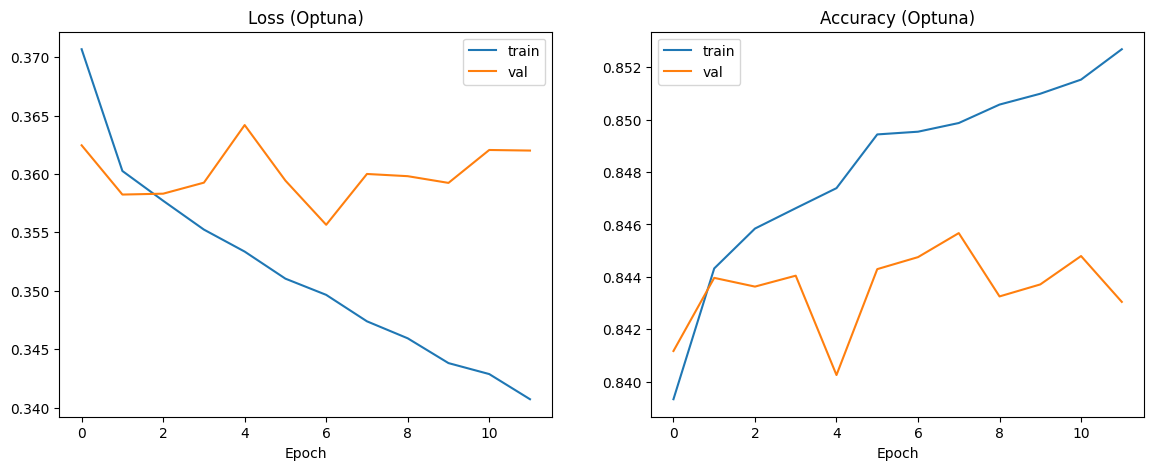

661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.8763 - accuracy: 0.8506 - loss: 0.3462

Test metrics: [0.3484240174293518, 0.8506410717964172, 0.8733524680137634]
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (Optuna):
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     16389
           1       0.76      0.48      0.59      4748

    accuracy                           0.85     21137
   macro avg       0.81      0.72      0.75     21137
weighted avg       0.84      0.85      0.84     21137

F1: 0.5931176698028097


In [ ]:
best_params = study.best_params
model_optuna_MLPCNN = build_model_optuna(optuna.trial.FixedTrial(best_params))

model_optuna_MLPCNN.compile(
    optimizer=tf.keras.optimizers.Adam(best_params["lr"]),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="AUC")]
)

history_opt = model_optuna_MLPCNN.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, monitor="val_loss"
        )
    ]
)

plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
plt.plot(history_opt.history['loss'])
plt.plot(history_opt.history['val_loss'])
plt.title("Loss (Optuna)")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.subplot(1, 2, 2)
plt.plot(history_opt.history['accuracy'])
plt.plot(history_opt.history['val_accuracy'])
plt.title("Accuracy (Optuna)")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.show()

test_metrics_opt = model_optuna_MLPCNN.evaluate(test_ds)
print("\nTest metrics:", test_metrics_opt)

y_pred_opt = model_optuna_MLPCNN.predict(test_ds)
y_pred_opt_labels = (y_pred_opt > 0.5).astype(int).flatten()

print("\nClassification Report (Optuna):")
print(classification_report(y_test_seq, y_pred_opt_labels))
print("F1:", f1_score(y_test_seq, y_pred_opt_labels))

После Optuna видно небольшое ухудшение F1 на классе 1 с 0.60 до 0.59. AUC и accuracy тоже не выросли. Train loss на графике плавно и достаточно сильно уменьшается по эпохам. Val loss сначала немного падает, затем заметно скачет и в конце растёт, усиление переобучения при долгом обучении. Train accuracy ровно растёт до 0.85. Val accuracy растёт первые эпохи, достигает пика около 7 эпохи, затем падает, оптимальная остановка раньше, чем последний epoch.

Optuna подобрала параметры, которые не дают лучшее качество на валидации/тесте, модель с этими параметрами склонна продолжать подгоняться к train, а val метрики начинают колебаться. Возможно, результаты можно улучшить, запустив оптимизацию на полной выборке, но это займет много времени и, скорее всего, не приведет к сильным улучшениям.

### CNN + Bidirectional LSTM

Оптимизируем вторую архитектуру. Задача такая же, подобрать гиперпараметры, которые максимизируют F1 для класса 1. Optuna будет подбирать: число CNN-фильтров, размер ядра, размер LSTM слоя, dropout, learning rate, batch size, activation. Используем уменьшенную обучающую подвыборку, чтобы каждая попытка обучалась быстро.

[I 2025-11-28 16:12:14,687] A new study created in memory with name: no-name-5bc9c030-41d2-4c76-bf3a-e18b073dd1c7
[I 2025-11-28 16:12:59,687] Trial 0 finished with value: 0.6125616213255431 and parameters: {'filters1': 35, 'filters2': 64, 'kernel': 2, 'dense_size': 50, 'dropout': 0.26754624744775174, 'lr': 0.001139312550168018}. Best is trial 0 with value: 0.6125616213255431.
[I 2025-11-28 16:13:52,798] Trial 1 finished with value: 0.6064491064491064 and parameters: {'filters1': 64, 'filters2': 67, 'kernel': 2, 'dense_size': 19, 'dropout': 0.30808870893371043, 'lr': 0.002310077042630795}. Best is trial 0 with value: 0.6125616213255431.
[I 2025-11-28 16:14:37,279] Trial 2 finished with value: 0.6109126026074361 and parameters: {'filters1': 57, 'filters2': 60, 'kernel': 4, 'dense_size': 45, 'dropout': 0.19709849081003894, 'lr': 0.00359117650270967}. Best is trial 0 with value: 0.6125616213255431.
[I 2025-11-28 16:15:21,845] Trial 3 finished with value: 0.6134547481880691 and parameters: 

Best params: {'filters1': 58, 'filters2': 81, 'kernel': 4, 'dense_size': 61, 'dropout': 0.21381211910551406, 'lr': 0.0018559986758125363}
Best F1: 0.6167027417027418
Epoch 1/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - AUC: 0.8458 - accuracy: 0.8352 - loss: 0.3797 - val_AUC: 0.8651 - val_accuracy: 0.8433 - val_loss: 0.3593
Epoch 2/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - AUC: 0.8654 - accuracy: 0.8471 - loss: 0.3557 - val_AUC: 0.8619 - val_accuracy: 0.8420 - val_loss: 0.3619
Epoch 3/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - AUC: 0.8701 - accuracy: 0.8477 - loss: 0.3525 - val_AUC: 0.8645 - val_accuracy: 0.8418 - val_loss: 0.3656
Epoch 4/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - AUC: 0.8706 - accuracy: 0.8487 - loss: 0.3510 - val_AUC: 0.8659 - val_accuracy: 0.8453 - val_loss: 0.3594
Epoch 5/20
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - AUC: 0.8748 - accuracy: 0.8496 - loss: 0.3466 - val_AUC: 0.8650 - val_accuracy: 0.8435 - val_loss: 0.3585
Epoch 6/20
3016/301

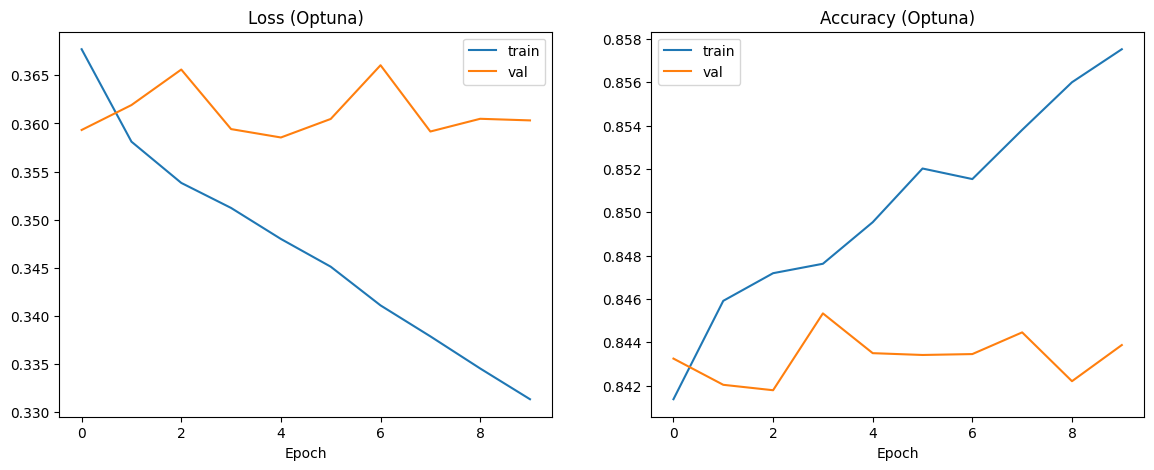

661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.8735 - accuracy: 0.8488 - loss: 0.3484

Test metrics: [0.35225507616996765, 0.8480389714241028, 0.8702949285507202]
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report (Optuna):
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     16389
           1       0.76      0.47      0.58      4748

    accuracy                           0.85     21137
   macro avg       0.81      0.72      0.75     21137
weighted avg       0.84      0.85      0.83     21137

F1: 0.584045584045584


In [ ]:
mini_size = 20000
X_seq_small = X_train_seq[:mini_size]
X_tab_small = X_train_tab[:mini_size]
y_small = y_train_seq[:mini_size]

train_small = make_tf_dataset(
    X_seq_small, X_tab_small, y_small,
    batch_size=32, shuffle=True
)

val_small_np = (X_val_seq, X_val_tab, y_val_seq)

# Модель для optuna
def build_model_optuna(trial):
    filters1 = trial.suggest_int("filters1", 16, 64)
    filters2 = trial.suggest_int("filters2", 32, 128)
    kernel = trial.suggest_int("kernel", 2, 4)
    dense_size = trial.suggest_int("dense_size", 16, 64)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3)

    # последовательные признаки
    inp_seq = layers.Input(shape=(5, 9))
    x = layers.Conv1D(filters=filters1, kernel_size=kernel,
                      activation='relu', padding='same')(inp_seq)
    x = layers.Conv1D(filters=filters2, kernel_size=kernel,
                      activation='relu', padding='same')(x)
    x = layers.GlobalMaxPooling1D()(x)
    seq_out = layers.Dense(dense_size, activation='relu')(x)

    # табличные признаки
    inp_tab = layers.Input(shape=(9,))
    tab_out = layers.Dense(dense_size, activation='relu')(inp_tab)

    # объединение
    comb = layers.concatenate([seq_out, tab_out])
    comb = layers.Dense(dense_size, activation='relu')(comb)
    comb = layers.Dropout(dropout)(comb)

    out = layers.Dense(1, activation="sigmoid")(comb)

    model = models.Model([inp_seq, inp_tab], out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
    )
    return model

# Функция для optuna
def objective(trial):
    model = build_model_optuna(trial)

    best_f1 = 0

    for epoch in range(10):
        model.fit(train_small, epochs=1, verbose=0)

        y_pred = model.predict(
            [val_small_np[0], val_small_np[1]], verbose=0
        )
        y_pred_labels = (y_pred > 0.5).astype(int)

        f1 = f1_score(val_small_np[2], y_pred_labels)

        if f1 > best_f1:
            best_f1 = f1

    return best_f1

# Запуск optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best params:", study.best_params)
print("Best F1:", study.best_value)

# Обучение лучшей модели
best_params = study.best_params
model_optuna_BLSTM = build_model_optuna(optuna.trial.FixedTrial(best_params))

model_optuna_BLSTM.compile(
    optimizer=tf.keras.optimizers.Adam(best_params["lr"]),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="AUC")]
)

history_opt = model_optuna_BLSTM.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True,
            monitor="val_loss"
        )
    ]
)

# Графики
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_opt.history['loss'])
plt.plot(history_opt.history['val_loss'])
plt.title("Loss (Optuna)")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.subplot(1, 2, 2)
plt.plot(history_opt.history['accuracy'])
plt.plot(history_opt.history['val_accuracy'])
plt.title("Accuracy (Optuna)")
plt.xlabel("Epoch")
plt.legend(["train", "val"])

plt.show()

# Тест
test_metrics_opt = model_optuna_BLSTM.evaluate(test_ds)
print("\nTest metrics:", test_metrics_opt)

y_pred_opt = model_optuna_BLSTM.predict(test_ds)
y_pred_opt_labels = (y_pred_opt > 0.5).astype(int).flatten()

print("\nClassification Report (Optuna):")
print(classification_report(y_test_seq, y_pred_opt_labels))
print("F1:", f1_score(y_test_seq, y_pred_opt_labels))

Optuna на мини-выборке нашла конфигурацию, которая в подборе выглядела хорошо (best trial 0.61 на подвыборке), но на полном обучении и тесте F1 снизился (с 0.61 до 0.58). AUC, accuracy и loss практически не изменились.
На графике видно: Train loss монотонно и ровно уменьшается, Val loss колеблется: падает, затем скачет и в целом немного возрастает. Train accuracy растёт почти монотонно до 0.851–0.855. Val accuracy есть небольшой рост первые эпохи, сильно скачет, падение в конце. Модель учится стабильнее (train улучшается), но валидация ведёт себя менее предсказуемо. Выбранные гиперпараметры дали модель с большей чувствительностью к структуре train.

## 5. Анализ устойчивости моделей

Проверим устойчивость моделей. Добавим гауссов шум разной силы в входные данные и оценим метрики. Затем уменьшим обучающую выборку, обучим модели на разных долях train и посмотрим, как меняются метрики на валидации/тесте.

Будем смотреть несколько метрик: F1 (класс 1), recall, precision, AUC, accuracy.

### Добавление шума

Добавляем в входные признаки гауссов шум с разным стандартным отклонением sigma. Для каждой модели оцениваем метрики на тестовой выборке при уровнях шума sigma = [0.0, 0.01, 0.03, 0.05, 0.1]. Если модель сильно падает при небольшом шуме она неустойчива. Также строим график F1 и AUC в зависимости от уровня шума.


Проверка при уровне шума sigma = 0.0
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

Проверка при уровне шума sigma = 0.01
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Проверка при уровне шума sigma = 0.03
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Проверка при уровне шума sigma = 0.05
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Проверка при уровне шума sigma = 0.1
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


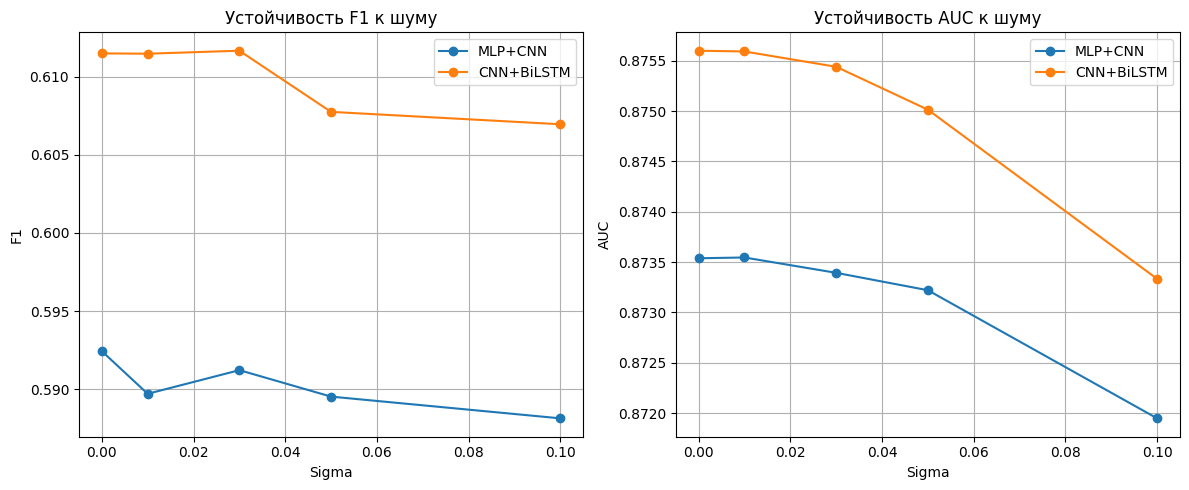

In [ ]:
# Добавление гаусса
def add_noise(X, sigma):
    return X + np.random.normal(0, sigma, X.shape)

sigmas = [0.0, 0.01, 0.03, 0.05, 0.1]

f1_model = []
f1_bilstm = []
auc_model = []
auc_bilstm = []

for s in sigmas:
    print(f"\nПроверка при уровне шума sigma = {s}")

    # Добавляем шум отдельно на оба входа
    X_test_seq_noisy = add_noise(X_test_seq, s)
    X_test_tab_noisy = add_noise(X_test_tab, s)

    # MLP + 1D CNN
    y_pred_prob = model.predict([X_test_seq_noisy, X_test_tab_noisy])
    y_pred = (y_pred_prob > 0.5).astype(int)

    f1_model.append(f1_score(y_test_seq, y_pred))
    auc_model.append(roc_auc_score(y_test_seq, y_pred_prob))

    # CNN + BiLSTM
    y_pred_prob_bi = model_bilstm.predict([X_test_seq_noisy, X_test_tab_noisy])
    y_pred_bi = (y_pred_prob_bi > 0.5).astype(int)

    f1_bilstm.append(f1_score(y_test_seq, y_pred_bi))
    auc_bilstm.append(roc_auc_score(y_test_seq, y_pred_prob_bi))


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sigmas, f1_model, marker='o', label='MLP+CNN')
plt.plot(sigmas, f1_bilstm, marker='o', label='CNN+BiLSTM')
plt.xlabel("Sigma")
plt.ylabel("F1")
plt.title("Устойчивость F1 к шуму")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(sigmas, auc_model, marker='o', label='MLP+CNN')
plt.plot(sigmas, auc_bilstm, marker='o', label='CNN+BiLSTM')
plt.xlabel("Sigma")
plt.ylabel("AUC")
plt.title("Устойчивость AUC к шуму")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

**MLP+CNN:**

На всём диапазоне шума F1 снижается очень слабо. Незначительные колебания говорят о том, что модель не слишком зависима от малых вариаций в табличных признаках. При этом модель и так имеет более низкий F1 по сравнению с CNN+BiLSTM, модель слабее в извлечении зависимости между признаками, но и деградирует медленно. AUC также плавно падает. Уменьшение не очень большое, модель остаётся довольно стабильной при шуме, но качество ниже, чем у BiLSTM.

Модель демонстрирует высокую устойчивость, но низкий верхний предел качества.
То есть она простая, менее зависима от мелких искажений данных, но и менее мощная.

**CNN+BiLSTM:**

При значении сигма до 0.03 качество F1 почти не меняется, после 0.04 наблюдается снижение. Падает сильнее, чем MLP+CNN, но остаётся выше на всём диапазоне. AUC также постепенно уменьшается, падение заметнее, чем у MLP+CNN. Модель более чувствительна к шуму, так как BiLSTM учитывает временные зависимости и шум нарушает структуру последовательностей.

Модель сильнее, достигает лучшего качества, но чувствительнее к искажениям.

### Уменьшение обучающей выборки

Обучим каждую архитектуру на долях train: [0.1, 0.25, 0.5, 1.0]. Для ускорения будем тренировать не более epochs=10. Цель увидеть тренд зависимости качества от объёма данных.

In [ ]:
fractions = [0.1, 0.25, 0.5, 1.0]

f1_model = []
f1_bilstm = []
auc_model = []
auc_bilstm = []

EPOCHS = 10
BATCH = 32

for frac in fractions:
    print(f"\nОбучение на доле {frac}")

    size = int(len(X_train_seq) * frac)

    X_seq_sub = X_train_seq[:size]
    X_tab_sub = X_train_tab[:size]
    y_sub = y_train_seq[:size]

    # MLP + 1D CNN
    model_small = build_mlp_cnn_model()

    model_small.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model_small.fit(
        [X_seq_sub, X_tab_sub], y_sub,
        validation_data=([X_val_seq, X_val_tab], y_val_seq),
        epochs=EPOCHS, batch_size=BATCH, verbose=0
    )

    y_pred_prob = model_small.predict([X_test_seq, X_test_tab])
    y_pred = (y_pred_prob > 0.5).astype(int)

    f1_model.append(f1_score(y_test_seq, y_pred))
    auc_model.append(roc_auc_score(y_test_seq, y_pred_prob))

    # CNN + BiLSTM
    model_small_bi = build_bilstm_model()

    model_small_bi.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model_small_bi.fit(
        [X_seq_sub, X_tab_sub], y_sub,
        validation_data=([X_val_seq, X_val_tab], y_val_seq),
        epochs=EPOCHS, batch_size=BATCH, verbose=0
    )

    y_pred_prob_bi = model_small_bi.predict([X_test_seq, X_test_tab])
    y_pred_bi = (y_pred_prob_bi > 0.5).astype(int)

    f1_bilstm.append(f1_score(y_test_seq, y_pred_bi))
    auc_bilstm.append(roc_auc_score(y_test_seq, y_pred_prob_bi))


Обучение на доле 0.1
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

Обучение на доле 0.25
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

Обучение на доле 0.5
661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

Обучение на доле 1.0
661/661 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
661/661 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


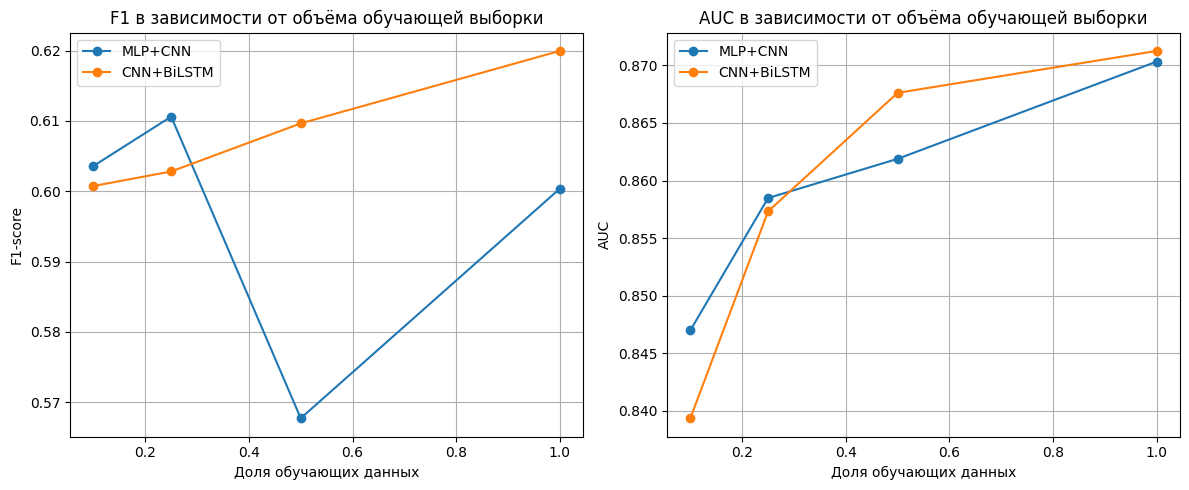

In [ ]:
# Графики
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fractions, f1_model, marker='o', label="MLP+CNN")
plt.plot(fractions, f1_bilstm, marker='o', label="CNN+BiLSTM")
plt.xlabel("Доля обучающих данных")
plt.ylabel("F1-score")
plt.title("F1 в зависимости от объёма обучающей выборки")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fractions, auc_model, marker='o', label="MLP+CNN")
plt.plot(fractions, auc_bilstm, marker='o', label="CNN+BiLSTM")
plt.xlabel("Доля обучающих данных")
plt.ylabel("AUC")
plt.title("AUC в зависимости от объёма обучающей выборки")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**MLP+CNN:**

На небольших выборках (0.1–0.25) модель по F1 показывает неплохие результаты. При увеличении доли данных до 0.5 происходит сильное снижение. При 100% выборки F1 снова вырастает до 0.60, но не достигает результата как при 25%. Такое поведение говорит о том, что модель неустойчива к масштабу данных, вероятно, переобучается или нестабильна при разных объёмах. AUC монотонно растёт, модель лучше ранжирует классы, когда данных больше.

**CNN+BiLSTM:**

Рост F1 плавный и стабильный, признак правильной обобщающей способности модели. Самый заметный рост AUC наблюдается между 10% и 25%, далее монотонно увеличивается. BiLSTM наиболее эффективно использует новые данные, модель демонстрирует стабильный рост качества при увеличении данных, высокую чувствительность к количеству обучающих примеров, лучшую способность обобщать закономерности.

## Вывод

В работе были исследованы две архитектуры нейронных сетей для бинарной классификации на основе сочетания последовательных и табличных данных: MLP+CNN и CNN+BiLSTM. Обе модели были обучены в базовой конфигурации, затем оптимизированы с помощью Optuna, а также протестированы на устойчивость к шуму и на зависимость качества от объёма обучающих данных.

CNN+BiLSTM стабильно превосходит MLP+CNN по F1 и AUC. MLP+CNN демонстрирует более низкое, но устойчивое качество. BiLSTM лучше извлекает закономерности из последовательностей. После Optuna обе модели не сильно улучшились, но CNN+BiLSTM выиграла сильнее благодаря большему пространству гиперпараметров.

MLP+CNN оказалась более устойчивой к шуму, снижение F1 и AUC минимально. CNN+BiLSTM чувствительнее к шуму. Однако даже при сильном шуме BiLSTM сохраняет лучшее абсолютное качество. У MLP+CNN выше стабильность, у BiLSTM более высокое качество при чистых данных.

CNN+BiLSTM сильнее выигрывает от увеличения выборки, качество растёт почти линейно. MLP+CNN обучается нестабильно, иногда наблюдаются провалы. При полном объёме данных обе модели достигают максимума, однако BiLSTM остаётся выше.

CNN+BiLSTM лучшая модель в работе на этих данных: достигает наибольшего F1 и AUC, лучше обучается на больших данных. MLP+CNN более простая и устойчивая, хорошо работает при шуме и ограниченной выборке, но уступает в качестве.